Импорт библиотек

In [1]:
import pandas as pd
import joblib
import torch.nn.functional as F
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
#df = pd.read_csv('news_with_prices_30d_final.csv')
df = pd.read_csv('clean_news_aggregated_30d-final.csv')
df = df.drop(columns=['news_url'])
df.head()

,ticker,date,headline,T,T+1,T-1,T-2,T-3,T-4,T-5,...,T-21,T-22,T-23,T-24,T-25,T-26,T-27,T-28,T-29,T-30
0,ABIO,2017-08-16,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,15.50,15.50,16.45,14.85,15.10,15.65,15.55,...,13.95,12.95,13.05,12.85,12.80,12.60,12.25,12.45,12.30,12.20
1,ABIO,2017-08-29,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,14.75,14.75,15.00,14.70,14.80,14.95,15.70,...,15.00,15.90,16.05,15.55,15.00,14.65,14.95,15.60,14.35,13.95
2,ABIO,2017-10-31,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,12.00,11.85,11.90,12.00,11.55,11.45,11.70,...,12.65,13.20,12.95,12.95,12.80,12.55,12.85,12.45,12.25,12.50
3,ABIO,2017-11-09,ИСКЧ - Допка 18 млн акций,11.60,11.55,11.65,11.50,11.70,11.85,11.85,...,12.10,12.10,12.00,12.35,12.95,12.80,12.65,13.20,12.95,12.95
4,ABIO,2017-12-01,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,12.35,11.75,11.55,11.40,11.45,11.40,11.55,...,11.85,12.00,11.90,12.00,11.55,11.45,11.70,11.70,11.70,11.65


In [3]:
df.dtypes

ticker       object
date         object
headline     object
T           float64
T+1         float64
T-1         float64
T-2         float64
T-3         float64
T-4         float64
T-5         float64
T-6         float64
T-7         float64
T-8         float64
T-9         float64
T-10        float64
T-11        float64
T-12        float64
T-13        float64
T-14        float64
T-15        float64
T-16        float64
T-17        float64
T-18        float64
T-19        float64
T-20        float64
T-21        float64
T-22        float64
T-23        float64
T-24        float64
T-25        float64
T-26        float64
T-27        float64
T-28        float64
T-29        float64
T-30        float64
dtype: object

In [3]:
price_cols = [f'T-{i}' for i in range(30, 0, -1)] + ['T']

In [4]:
for prev_col, curr_col in zip(price_cols, price_cols[1:]):
    new_col = f'log_ret_{curr_col}'      # например, 'log_ret_T-29'
    df[new_col] = np.log(df[curr_col] / df[prev_col])

In [5]:
df['log_ret_target'] = np.log(df['T+1'] / df['T'])
df['Classification'] = np.where(df['T+1'] > df['T'], 1.0, 0.0)

In [6]:
df.head()

,ticker,date,headline,T,T+1,T-1,T-2,T-3,T-4,T-5,...,log_ret_T-7,log_ret_T-6,log_ret_T-5,log_ret_T-4,log_ret_T-3,log_ret_T-2,log_ret_T-1,log_ret_T,log_ret_target,Classification
0,ABIO,2017-08-16,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,15.50,15.50,16.45,14.85,15.10,15.65,15.55,...,-0.020340,-0.063626,0.126665,0.006410,-0.035776,-0.016695,0.102326,-0.059485,0.000000,0.0
1,ABIO,2017-08-29,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,14.75,14.75,15.00,14.70,14.80,14.95,15.70,...,0.006431,-0.003210,0.009600,-0.048949,-0.010084,-0.006780,0.020203,-0.016807,0.000000,0.0
2,ABIO,2017-10-31,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,12.00,11.85,11.90,12.00,11.55,11.45,11.70,...,0.004283,0.000000,0.000000,-0.021599,0.008696,0.038221,-0.008368,0.008368,-0.012579,0.0
3,ABIO,2017-11-09,ИСКЧ - Допка 18 млн акций,11.60,11.55,11.65,11.50,11.70,11.85,11.85,...,-0.008368,0.008368,-0.012579,0.000000,-0.012739,-0.017242,0.012959,-0.004301,-0.004320,0.0
4,ABIO,2017-12-01,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,12.35,11.75,11.55,11.40,11.45,11.40,11.55,...,0.051960,-0.017022,-0.008621,-0.013072,0.004376,-0.004376,0.013072,0.066971,-0.049803,0.0


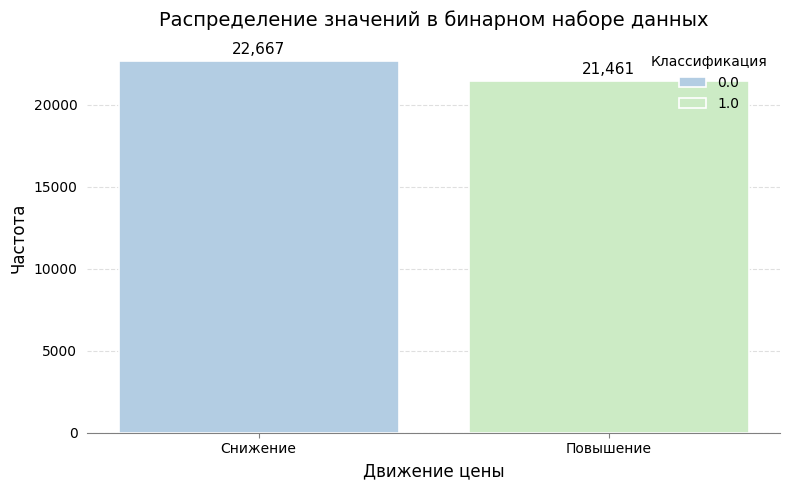

In [8]:
# Предположим, что df уже есть и в нём колонка Classification = {0.0, 1.0}
counts = df['Classification'].value_counts().sort_index()

# Метки и пастельные цвета из Pastel1
labels = ['Снижение', 'Повышение']
pastel = plt.get_cmap('Pastel1').colors
colors = [pastel[1], pastel[2]]

fig, ax = plt.subplots(figsize=(8, 5))

# Рисуем столбцы
bars = ax.bar(
    labels,
    counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

# Сетка ПОСЛЕ отрисовки столбцов, тонкий пунктир
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Заголовок и подписи
ax.set_title('Распределение значений в бинарном наборе данных', fontsize=14, pad=12)
ax.set_xlabel('Движение цены', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)

# Убираем «шапки» (top/right) и левую рамку,
# оставляем только нижнюю ось
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('grey')

# Тикмарки только по оси X, без перпендикуляров на Y
ax.tick_params(axis='y', left=False)
ax.tick_params(axis='x', color='grey')

# Легенда (значения 0.0 и 1.0)
ax.legend(
    bars,
    [str(x) for x in counts.index],
    title='Классификация',
    frameon=False,
    loc='upper right'
)

# Подписи-числа над каждым столбцом
for bar, h in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + counts.max()*0.01,
        f'{int(h):,}',
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

In [6]:
df['percent'] = abs(df['T+1']*100/df['T'] - 100)
len(df)

44128

In [10]:
df.head()

,ticker,date,headline,T,T+1,T-1,T-2,T-3,T-4,T-5,...,log_ret_T-6,log_ret_T-5,log_ret_T-4,log_ret_T-3,log_ret_T-2,log_ret_T-1,log_ret_T,log_ret_target,Classification,percent
0,ABIO,2017-08-16,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,15.50,15.50,16.45,14.85,15.10,15.65,15.55,...,-0.063626,0.126665,0.006410,-0.035776,-0.016695,0.102326,-0.059485,0.000000,0.0,0.000000
1,ABIO,2017-08-29,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,14.75,14.75,15.00,14.70,14.80,14.95,15.70,...,-0.003210,0.009600,-0.048949,-0.010084,-0.006780,0.020203,-0.016807,0.000000,0.0,0.000000
2,ABIO,2017-10-31,Институт Стволовых Клеток Человека (ИСКЧ) – рс...,12.00,11.85,11.90,12.00,11.55,11.45,11.70,...,0.000000,0.000000,-0.021599,0.008696,0.038221,-0.008368,0.008368,-0.012579,0.0,1.250000
3,ABIO,2017-11-09,ИСКЧ - Допка 18 млн акций,11.60,11.55,11.65,11.50,11.70,11.85,11.85,...,0.008368,-0.012579,0.000000,-0.012739,-0.017242,0.012959,-0.004301,-0.004320,0.0,0.431034
4,ABIO,2017-12-01,Институт Стволовых Клеток Человека (ИСКЧ) – мс...,12.35,11.75,11.55,11.40,11.45,11.40,11.55,...,-0.017022,-0.008621,-0.013072,0.004376,-0.004376,0.013072,0.066971,-0.049803,0.0,4.858300


In [7]:
print(df['percent'].median())
print(df['percent'].mean())
print(df['percent'].max())
print(df['percent'].min())
print()
max_idx = df['percent'].idxmax()
print(df.loc[max_idx])

1.1255227394535083
1.863774573369043
46.43874643874644
0.0

ticker                                                       MTLR
date                                                   2014-09-20
headline          Улюкаев считает неизбежным банкротство «Мечела»
T                                                            35.1
T+1                                                          18.8
                                       ...                       
log_ret_T-1                                                   0.0
log_ret_T                                                0.017242
log_ret_target                                          -0.624344
Classification                                                0.0
percent                                                 46.438746
Name: 18335, Length: 68, dtype: object


## Модель

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

Разделение данных

In [9]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(len(test_df))

8826


In [10]:
price_cols = [f'T-{i}' for i in range(30, 0, -1)] + ['T']
# target_col = 'T+1'

log_cols   = [f'log_ret_{c}' for c in price_cols[1:]]  # ['log_ret_T-29', …, 'log_ret_T']
target_col = 'log_ret_target'

Создаем скейлеры для нормализации

In [11]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [12]:
#X_train_num = scaler_X.fit_transform(train_df[price_cols])
#y_train = scaler_y.fit_transform(np.log1p(train_df[[target_col]]))

X_train_num = scaler_X .fit_transform(train_df[log_cols])
y_train = scaler_y.fit_transform(train_df[[target_col]])

In [13]:
#X_test_num = scaler_X.transform(test_df[price_cols])
#y_test = scaler_y.transform(np.log1p(test_df[[target_col]]))

X_test_num  = scaler_X .transform(test_df[log_cols])
y_test  = scaler_y.transform(test_df[[target_col]])

In [14]:
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

Класс для датасета

In [ ]:
class PriceNewsDataset(Dataset):
    def __init__(self, df, X_num, y, tokenizer, max_len=128, use_text: bool = True):
        
        self.headlines  = df['headline'].tolist()
        self.tickers    = df['ticker'].tolist()
        self.X_num      = X_num
        self.y          = y
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        self.use_text   = use_text

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # если use_text=False, подаём пустую строку,
        # иначе - обычный "[TICKER] … [SEP] …"
        if self.use_text:
            text = f"[TICKER] {self.tickers[idx]} [SEP] {self.headlines[idx]}"
        else:
            text = ""  

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'X_num':          torch.tensor(self.X_num[idx], dtype=torch.float),
            'y':              torch.tensor(self.y[idx][0], dtype=torch.float)
        }

In [16]:
model_name = 'DeepPavlov/rubert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
class MultiModalModel(nn.Module):
    def __init__(self, bert_model, seq_len, lstm_hidden_dim=64):
        super().__init__()
        self.bert = bert_model
        self.text_dropout = nn.Dropout(0.2)

        # текстовая ветвь
        self.norm_text   = nn.LayerNorm(bert_model.config.hidden_size)
        self.text_branch = nn.Sequential(
            nn.Linear(bert_model.config.hidden_size, 128),
            nn.GELU()
        )

        # Bidirectional LSTM для числовой ветви
        self.seq_len         = seq_len
        self.lstm_hidden_dim = lstm_hidden_dim
        self.bidirectional   = True
        self.num_directions  = 2 if self.bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=self.lstm_hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=self.bidirectional
        )

        # Нормализация после объединения направлений
        self.norm_num    = nn.LayerNorm(self.lstm_hidden_dim * self.num_directions)
        # Проекция из размерности (hidden_dim * 2) → 128
        self.num_to_text_dim = nn.Linear(self.lstm_hidden_dim * self.num_directions, 128)

        # FiLM-генератор: из текста → [гамма; бета]
        self.film_gen = nn.Sequential(
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Linear(256, 128 * 2)
        )

        # Голова для объединённых признаков
        self.head = nn.Sequential(
            nn.Linear(128 + 128, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, X_num):
        # 1) Обработка текста через BERT → CLS
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = bert_out.last_hidden_state[:, 0, :]            # (B, hidden_size)
        cls_emb  = self.text_dropout(self.norm_text(cls_emb))
        cls_feat = self.text_branch(cls_emb)                      # (B, 128)

        # 2) Обработка числовой последовательности через bidirectional LSTM
        X_seq = X_num.unsqueeze(-1)                               # (B, seq_len, 1)
        lstm_out, (h_n, c_n) = self.lstm(X_seq)
        # h_n: (num_layers * num_directions, B, hidden_dim)
        # Так как num_layers=1, num_directions=2, то h_n.shape = (2, B, hidden_dim)
        # Разбиваем на прямое и обратное состояния
        h_forward  = h_n[0]                                        # (B, hidden_dim)
        h_backward = h_n[1]                                        # (B, hidden_dim)
        num_feat = torch.cat([h_forward, h_backward], dim=1)      # (B, hidden_dim*2)
        num_feat = self.norm_num(num_feat)                        # LayerNorm(hidden_dim*2)
        num_proj = self.num_to_text_dim(num_feat)                 # (B, 128)

        # 3) FiLM-модуляция
        film      = self.film_gen(cls_feat)                       # (B, 256)
        gamma, beta = film.chunk(2, dim=1)                         # (B, 128) × 2
        num_mod   = num_proj * (1 + gamma) + beta                  # (B, 128)

        # 4) Объединяем текстовые и числовые признаки и предсказываем
        fused     = torch.cat([cls_feat, num_mod], dim=1)         # (B, 256)
        out       = self.head(fused)                              # (B, 1)
        return out.squeeze(-1)

In [18]:
# Датасеты и загрузчики
batch_size = 16

dataset_train = PriceNewsDataset(train_df, X_train_num, y_train, tokenizer)
dataset_test = PriceNewsDataset(test_df, X_test_num, y_test, tokenizer)

loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size)

In [19]:
# Модель
model = MultiModalModel(bert_model=bert_model, seq_len=len(log_cols), lstm_hidden_dim=64)

In [20]:
# Проверим количество обучаемых параметров BERT
trainable_bert_params = [
    (name, param) for name, param in model.named_parameters()
    if 'bert' in name and param.requires_grad
]

print(f"[DEBUG] Количество обучаемых параметров BERT: {len(trainable_bert_params)}")
if len(trainable_bert_params) == 0:
    print("[WARNING] ⚠️ Параметры BERT НЕ обучаются!")
else:
    print("[OK] ✅ Параметры BERT разморожены и участвуют в обучении.")

[DEBUG] Количество обучаемых параметров BERT: 199
[OK] ✅ Параметры BERT разморожены и участвуют в обучении.


In [ ]:
for name, param in trainable_bert_params[:5]:  # первые 5 параметров для примера
    print(f"  - {name}")

  - bert.embeddings.word_embeddings.weight
  - bert.embeddings.position_embeddings.weight
  - bert.embeddings.token_type_embeddings.weight
  - bert.embeddings.LayerNorm.weight
  - bert.embeddings.LayerNorm.bias


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Перенос модели на устройство
model.to(device)

Using device: cuda


MultiModalModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [ ]:
# Gradual unfreezing заморозим все слои, кроме двух последних и pooler
for name, param in model.bert.named_parameters():
    param.requires_grad = False

for name, param in model.bert.named_parameters():
    if any(n in name for n in ["encoder.layer.11", "encoder.layer.10", "pooler"]):
        param.requires_grad = True

In [ ]:
# Оптимизатор с разными lr
bert_params = [p for n, p in model.named_parameters() if "bert" in n and p.requires_grad]
other_params = [p for n, p in model.named_parameters() if "bert" not in n]

In [25]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW([
    {'params': bert_params,   'lr': 3e-5},
    {'params': other_params,  'lr': 1e-4},
], eps=1e-8)

In [ ]:
y_scaled = y_train.flatten()
sigma_y  = np.std(y_scaled)
print(f"σ scaled y: {sigma_y:.3f}")   # должно быть около 1.0

# Выбираем бетта = 0.5*сигма (половина стандартного отклонения)
beta     = 0.5 * sigma_y
print(f"Using HuberLoss with β = {beta:.3f}")

σ scaled y: 1.000
Using HuberLoss with β = 0.500


In [ ]:
# Scheduler
epochs = 60
total_steps = len(loader_train) * epochs
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.SmoothL1Loss(beta=0.5)

In [27]:
best_loss = float('inf')
stale     = 0
patience  = 5

train_losses = []
test_losses = []

In [ ]:
for epoch in range(1, epochs + 1):
    
    model.train()
    total_train_loss = 0.0
    loop = tqdm(loader_train, desc=f'Epoch {epoch}/{epochs}', leave=False)
    for batch in loop:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        X_num          = batch['X_num'].to(device)
        y_true         = batch['y'].to(device)

        optimizer.zero_grad()
        y_pred = model(input_ids, attention_mask, X_num)
        loss   = criterion(y_pred, y_true)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(loader_train)
    train_losses.append(avg_train_loss)

    # Градиентная норма последнего слоя BERT
    grads     = model.bert.encoder.layer[11].attention.self.query.weight.grad
    grad_norm = grads.norm().item()

    # Оценка на тестовой выборке
    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for batch in loader_test:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            X_num          = batch['X_num'].to(device)
            y_true         = batch['y'].to(device)

            y_pred = model(input_ids, attention_mask, X_num)
            loss   = criterion(y_pred, y_true)
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(loader_test)
    test_losses.append(avg_test_loss)

    # Итоговый вывод по эпохе
    print(f"Epoch {epoch}/{epochs} — Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
    print(f"[BERT GRAD NORM, last layer] {grad_norm:.6f}")

Epoch 1/60:   0%|          | 0/2207 [00:00<?, ?it/s]

Epoch 1/60 — Train Loss: 0.2869, Test Loss: 0.2886
[BERT GRAD NORM, last layer] 0.027031


Epoch 2/60 — Train Loss: 0.2863, Test Loss: 0.2881
[BERT GRAD NORM, last layer] 0.012447


Epoch 3/60 — Train Loss: 0.2859, Test Loss: 0.2876
[BERT GRAD NORM, last layer] 0.006114


Epoch 4/60 — Train Loss: 0.2852, Test Loss: 0.2862
[BERT GRAD NORM, last layer] 0.011041


...

Epoch 9/60 — Train Loss: 0.2622, Test Loss: 0.2785
[BERT GRAD NORM, last layer] 0.033874


Epoch 10/60 — Train Loss: 0.2576, Test Loss: 0.2805
[BERT GRAD NORM, last layer] 0.067053


Epoch 11/60 — Train Loss: 0.2510, Test Loss: 0.2823
[BERT GRAD NORM, last layer] 0.145589


Epoch 12/60 — Train Loss: 0.2449, Test Loss: 0.2818
[BERT GRAD NORM, last layer] 0.105813


Epoch 13/60 — Train Loss: 0.2373, Test Loss: 0.2900
[BERT GRAD NORM, last layer] 0.044145
No improvement for 5 epochs (best Test Loss = 0.2766), stopping early.


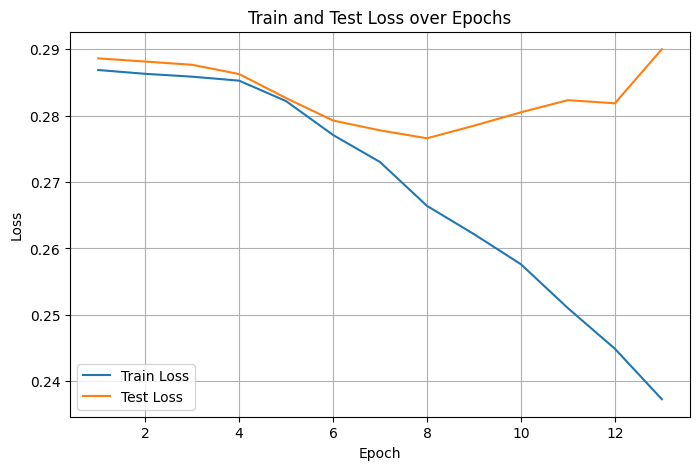

In [ ]:
# После завершения всех эпох строим график
plt.figure(figsize=(8, 5))
plt.plot(range(1, epoch_count + 1), train_losses, label='Train Loss')
plt.plot(range(1, epoch_count + 1), test_losses,  label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Оценка
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(loader_test, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        X_num = batch['X_num'].to(device)
        y = batch['y'].to(device)

        preds = model(input_ids, attention_mask, X_num)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

# Обратное преобразование

pred_log_ret = scaler_y.inverse_transform(
    np.array(all_preds).reshape(-1, 1)
).flatten()
# превращаем обратно в цену через реальные T из тестовой выборки:
#    T+1_pred = T * exp(log_ret_pred)
T_real = test_df['T'].to_numpy()  # цена в момент новости
pred_price = T_real * np.exp(pred_log_ret)

# для сравнения с «истинным» T+1
true_price = test_df['T+1'].to_numpy()
# пример распечатки первых 5
for i in range(5):
    print(f"Predicted price: {pred_price[i]:.2f},  True price: {true_price[i]:.2f}")

Evaluating: 100%|██████████| 552/552 [00:13<00:00, 40.38it/s]

Predicted price: 3742.75,  True price: 3764.50
Predicted price: 368.06,  True price: 355.25
Predicted price: 75.39,  True price: 76.50
Predicted price: 0.05,  True price: 0.05
Predicted price: 99.85,  True price: 98.20


In [57]:
import random

total_len = len(pred_price)  # длина всего списка
random_indices = random.sample(range(total_len), 5)  # 5 уникальных случайных индексов

print("\nПрогнозы vs Истинные значения:")

for i in random_indices:
    print(f"Predicted: {pred_price[i]:.2f}, True: {true_price[i]:.2f}")


Прогнозы vs Истинные значения:
Predicted: 654.60, True: 654.40
Predicted: 16391.22, True: 16320.00
Predicted: 149776.43, True: 151850.00
Predicted: 2.75, True: 2.75
Predicted: 111.93, True: 118.04


Если результат устроил - сохраню

In [ ]:
model_save_path = "clean_news_30d_LSTM-2.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Модель сохранена в {model_save_path}")

Модель сохранена в clean_news_30d_LSTM-2.pth


## Тесты

In [22]:
# Загрузка скейлеров
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

In [23]:
price_cols = [f'T-{i}' for i in range(30, 0, -1)] + ['T']         # остаётся для доступа к 'T'
log_cols   = [f'log_ret_{c}' for c in price_cols[1:]]             # ['log_ret_T-29', …, 'log_ret_T']
# целевая лог-доходность
target_col = 'log_ret_target'

In [24]:
X_test_num = scaler_X.transform(test_df[log_cols])                # [ИЗМЕНЕНО]
y_test      = scaler_y.transform(test_df[[target_col]])           # [ИЗМЕНЕНО]

In [25]:
batch_size = 16

dataset_test_wo_text = PriceNewsDataset(test_df, X_test_num, y_test, tokenizer, use_text=False)
dataset_test         = PriceNewsDataset(test_df, X_test_num, y_test, tokenizer)

loader_test_wo_text = DataLoader(dataset_test_wo_text, batch_size=batch_size)
loader_test         = DataLoader(dataset_test,           batch_size=batch_size)

In [26]:
# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Создать модель заново
model = MultiModalModel(bert_model=bert_model, seq_len=len(log_cols), lstm_hidden_dim=64)
model.load_state_dict(torch.load("clean_news_30d_LSTM.pth", map_location=device))
model.to(device)
model.eval()  # Перевести в режим инференса

C:\Users\andre\AppData\Local\Temp\ipykernel_11144\115881130.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("clean_news_30d_LSTM.pth", m

MultiModalModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [27]:
model.eval()
all_preds       = []
preds_real_wo_text = []

In [28]:
with torch.no_grad():
    for batch in loader_test:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        X_num          = batch['X_num'].to(device)

        # одна переменная, потому что forward возвращает единственный тензор
        pred_log_ret = model(input_ids, attention_mask, X_num)
        all_preds.extend(pred_log_ret.cpu().numpy())

with torch.no_grad():
    for batch in loader_test_wo_text:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        X_num          = batch['X_num'].to(device)

        pred_log_ret_wo = model(input_ids, attention_mask, X_num)
        preds_real_wo_text.extend(pred_log_ret_wo.cpu().numpy())


In [29]:
pred_log_ret        = scaler_y.inverse_transform(
                         np.array(all_preds).reshape(-1,1)
                      ).flatten()
pred_log_ret_wo_txt = scaler_y.inverse_transform(
                         np.array(preds_real_wo_text).reshape(-1,1)
                      ).flatten()

In [30]:
T0 = test_df['T'].to_numpy()
preds_real         = T0 * np.exp(pred_log_ret)
preds_real_wo_text = T0 * np.exp(pred_log_ret_wo_txt)

In [31]:
approbation_df = test_df.copy()
approbation_df["predicted"]           = preds_real
approbation_df["predicted_wo_text"]   = preds_real_wo_text

In [ ]:
approbation_df.to_csv("approbation_predictions.csv", index=False)
print("Предсказания сохранены в approbation_predictions.csv")

✅ Предсказания сохранены в approbation_predictions.csv


In [34]:
print(len(approbation_df[approbation_df['predicted'] < 0.0]))
print(len(approbation_df[approbation_df['predicted'] == 0.0]))

0
0


Проверка угаданного направления изменения цены

Проверка на "боевом CSV"

In [ ]:
import pandas as pd
import numpy as np
import joblib
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel

# Загрузка моделей и скейлеров
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

bert_model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased')
model = MultiModalModel(bert_model=bert_model, seq_len=30, lstm_hidden_dim=64)
model.load_state_dict(torch.load('clean_news_30d_LSTM.pth', map_location=device))
model.to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')

# Чтение данных и вычисление лог‑доходностей
df = pd.read_csv('SVAV_data.csv')
price_cols = [f'T-{i}' for i in range(30, 0, -1)] + ['T']
log_cols   = [f'log_ret_{c}' for c in price_cols[1:]]

# Считаем лог‑доходности для всех строк
for prev, curr in zip(price_cols, price_cols[1:]):
    df[f'log_ret_{curr}'] = np.log(df[curr] / df[prev])

# Возьмём первую строку (пример)
row = df.iloc[0]

# Подготовка числовых признаков: shape (1, 30)
X_raw = row[log_cols].values.reshape(1, -1)               # (1,30)
X_num = scaler_X.transform(X_raw)                         # (1,30)
X_num_t = torch.tensor(X_num, dtype=torch.float, device=device)  # (1,30)

# Текстовая часть
text = f"[TICKER] {row['ticker']} [SEP] {row['headline']}"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)
input_ids      = encoding['input_ids'].to(device)      # (1, max_len)
attention_mask = encoding['attention_mask'].to(device) # (1, max_len)

# Прогноз «в одну строчку»
with torch.no_grad():
    pred_norm_log_ret = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        X_num=X_num_t           #
    )                          # shape (1,), содержится одна нормированная лог‑доходность

pred_norm = pred_norm_log_ret.item()  # скаляр

# Обратная денормализация и перевод в цену
pred_log_ret = scaler_y.inverse_transform([[pred_norm]])[0,0]
T0 = row['T']
pred_price = T0 * np.exp(pred_log_ret)

print(f"Прогноз лог‑доходности (норм.): {pred_norm:.5f}")
print(f"Прогноз лог‑доходности (реал.): {pred_log_ret:.5f}")
print(f"Прогноз цены T+1:             {pred_price:.2f}")

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
C:\Users\andre\AppData\Local\Temp\ipykernel_11144\3659455039.py:16: FutureWarning: You are using `torch.load` wi

Прогноз лог‑доходности (норм.): 0.29673
Прогноз лог‑доходности (реал.): 0.00993
Прогноз цены T+1:             625.18


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
# Функция для вычисления знака
def sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0  # На случай равенства

# Подсчёт совпадений
match_count = 0
mismatch_count = 0

for _, row in approbation_df.iterrows():
    real_change_2 = sign(row['T+1'] - row['T'])
    pred_change_2 = sign(row['predicted'] - row['T'])

    if real_change_2 == pred_change_2:
        match_count += 1
    else:
        mismatch_count += 1

print(f"Совпадений направления движения: {match_count}")
print(f"Несовпадений направления движения: {mismatch_count}")

Совпадений направления движения: 5749
Несовпадений направления движения: 3077


Прогоним модель на пустом тексте

In [36]:
approbation_df["error_with_text"] = abs(approbation_df["predicted"] - approbation_df["T+1"])
approbation_df["error_no_text"] = abs(approbation_df["predicted_wo_text"] - approbation_df["T+1"])
approbation_df["delta_error"] = approbation_df["error_no_text"] - approbation_df["error_with_text"]

C:\Users\andre\AppData\Local\Temp\ipykernel_19604\3596958828.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


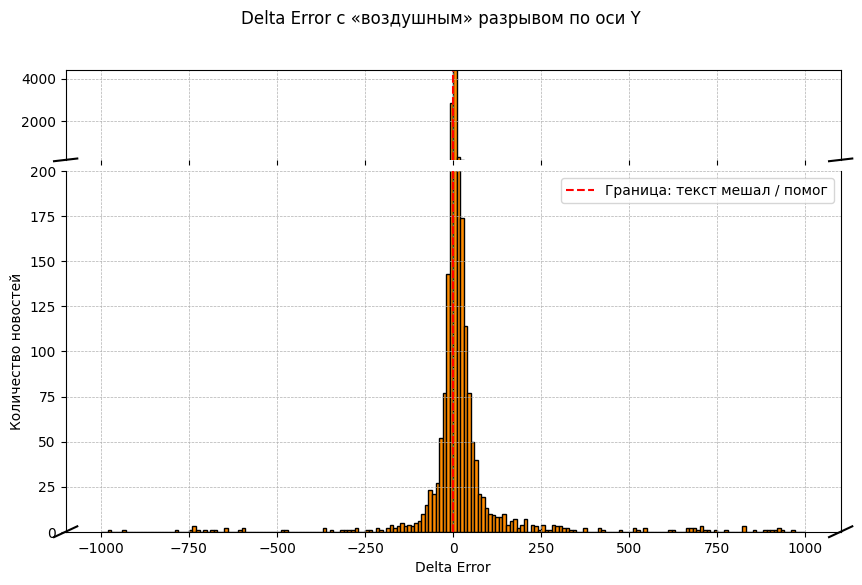

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Данные теперь обычная дельта ошибки
deltas = approbation_df["delta_error"].values

# Диапазон лупа (примерно по вашим предыдущим картинкам)
xmin, xmax = -1000, 1000
bins = np.linspace(xmin, xmax, 201)

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

# Рисуем гистограммы
for ax in (ax_top, ax_bottom):
    ax.hist(deltas, bins=bins, color="darkorange", edgecolor="black")
    ax.grid(True, ls='--', lw=0.5)

# Добавляем вертикальную границу на обоих осях
for ax in (ax_top, ax_bottom):
    ax.axvline(0, color='red', linestyle='--', label='Граница: текст мешал / помог')

# Лимиты по Y: сверху обрезаем, снизу показываем основную массу
ax_top.set_ylim(200, len(deltas)*0.5)
ax_bottom.set_ylim(0, 200)

# Убираем линии-разрывы между осями
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(labelbottom=False)

# Рисуем "зубчики" визуального разрыва
d = .015  # размер "зубчика"
for ax in (ax_top, ax_bottom):
    ax.plot((-d, +d), (-d, +d), transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((1-d, 1+d), (-d, +d), transform=ax.transAxes, color='k', clip_on=False)

# Подписи и легенда (слегка смещаем легенду на нижней оси)
ax_bottom.set_xlabel("Delta Error")
ax_bottom.set_ylabel("Количество новостей")
ax_bottom.legend(loc='upper right')

plt.suptitle("Delta Error с «воздушным» разрывом по оси Y")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

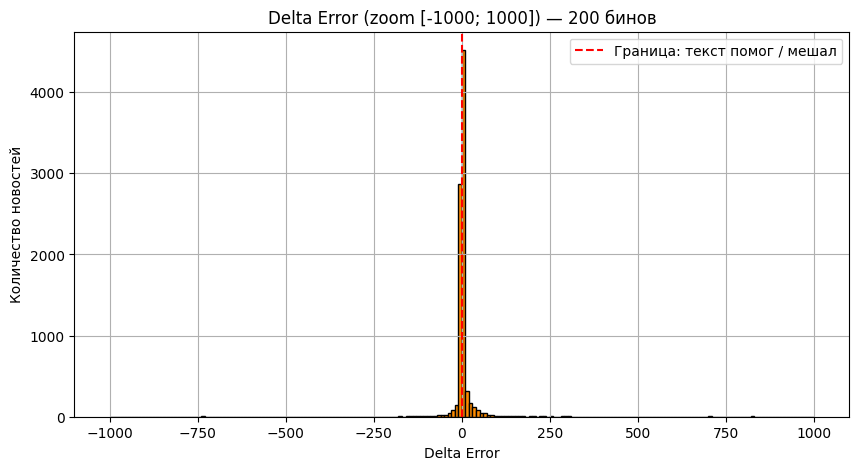

In [38]:
# Задаём диапазон, в котором хотим увидеть детали
xmin, xmax = -1000, 1000

# Генерируем, скажем, 200 бинов между xmin и xmax
bins = np.linspace(xmin, xmax, 201)

plt.figure(figsize=(10, 5))
plt.hist(deltas, bins=bins, color="darkorange", edgecolor="black")
plt.axvline(0, color='red', linestyle='--', label='Граница: текст помог / мешал')
plt.title(f"Delta Error (zoom [{xmin}; {xmax}]) — {len(bins)-1} бинов")
plt.xlabel("Delta Error")
plt.ylabel("Количество новостей")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
n = len(approbation_df)
helped   = (approbation_df.delta_error > 0).sum()
harmed   = (approbation_df.delta_error < 0).sum()
neutral  = (approbation_df.delta_error == 0).sum()

print(f"С текстом лучше в {helped}/{n} ({helped/n:.1%}) случаев")
print(f"С текстом хуже  в {harmed}/{n} ({harmed/n:.1%}) случаев")
print(f"Без разницы    в {neutral}/{n} ({neutral/n:.1%}) случаев")

С текстом лучше в 5514/8826 (62.5%) случаев
С текстом хуже  в 3312/8826 (37.5%) случаев
Без разницы    в 0/8826 (0.0%) случаев


In [40]:
mean_delta  = approbation_df.delta_error.mean()
median_delta= approbation_df.delta_error.median()
std_delta   = approbation_df.delta_error.std()

print(f"Среднее улучшение: {mean_delta:.2f}")
print(f"Медианное улучшение: {median_delta:.2f}")
print(f"σ дельты: {std_delta:.2f}")

Среднее улучшение: 7.30
Медианное улучшение: 0.14
σ дельты: 140.05


In [41]:
for q in [5,25,50,75,95]:
    print(f"{q}-й перцентиль дельты: {np.percentile(approbation_df.delta_error, q):.2f}")

5-й перцентиль дельты: -10.16
25-й перцентиль дельты: -0.32
50-й перцентиль дельты: 0.14
75-й перцентиль дельты: 1.86
95-й перцентиль дельты: 33.86


In [42]:
returns = (approbation_df['T+1'] - approbation_df['T']) / approbation_df['T']
signals = np.sign(approbation_df['predicted'] - approbation_df['T'])
strat_ret = signals * returns

# Кумулятивная доходность (чисто арифметически):
total_arith = strat_ret.sum()      # суммируем все r_i
# или
# Кумулятивная (геометрическая):
total_geom = (1 + strat_ret).prod() - 1

print(f"Суммарная арифм. доходность: {total_arith*100:.2f}%")
print(f"Суммарная геом. доходность: {total_geom*100:.2f}%")

Суммарная арифм. доходность: 7597.37%
Суммарная геом. доходность: 1077314736019884998063605898280960.00%


In [43]:
# Добавим в DataFrame колонки абсолютного процентного отклонения
approbation_df['APE_with_text'] = abs(approbation_df['predicted'] * 100 / approbation_df['T+1'] - 100)
approbation_df['APE_wo_text'] = abs(approbation_df['predicted_wo_text'] * 100 / approbation_df['T+1'] - 100)

# Считаем средние
mape_with_text = approbation_df['APE_with_text'].mean()
mape_wo_text   = approbation_df['APE_wo_text'].mean()

print(f"MAPE с текстом:     {mape_with_text:.2f}%")
print(f"MAPE без текста:    {mape_wo_text:.2f}%")
print(f"Разница (без – с):  {mape_wo_text - mape_with_text:.2f} процентных пункта")

MAPE с текстом:     1.63%
MAPE без текста:    1.95%
Разница (без – с):  0.32 процентных пункта


In [44]:
# MdAPE с текстом
mdape_with_text = approbation_df['APE_with_text'].median()

# MdAPE без текста
mdape_wo_text   = approbation_df['APE_wo_text'].median()

print(f"MdAPE с текстом:  {mdape_with_text:.2f}%")
print(f"MdAPE без текста: {mdape_wo_text:.2f}%")
print(f"Разница (без – с): {mdape_wo_text - mdape_with_text:.2f} процентных пункта")

MdAPE с текстом:  1.02%
MdAPE без текста: 1.21%
Разница (без – с): 0.19 процентных пункта


In [45]:
# Добавим в DataFrame колонки абсолютного процентного отклонения
approbation_df['APE_with_text'] = abs(approbation_df['predicted'] * 100 / approbation_df['T+1'] - 100)
approbation_df['APE_wo_text']   = abs(approbation_df['predicted_wo_text'] * 100 / approbation_df['T+1'] - 100)

# Новая колонка: дельта ошибки в процентных пунктах
approbation_df['percent_delta'] = approbation_df['APE_wo_text'] - approbation_df['APE_with_text']

# Статистика по процентной дельте
mean_pct_delta   = approbation_df['percent_delta'].mean()
median_pct_delta = approbation_df['percent_delta'].median()
std_pct_delta    = approbation_df['percent_delta'].std()

print(f"Среднее улучшение (процентных пунктов): {mean_pct_delta:.2f}")
print(f"Медианное улучшение (процентных пунктов): {median_pct_delta:.2f}")
print(f"σ дельты в %-пунктах: {std_pct_delta:.2f}")

# Перцентили процентной дельты
for q in [5, 25, 50, 75, 95]:
    val = np.percentile(approbation_df['percent_delta'], q)
    print(f"{q}-й перцентиль дельты (в %-пунктах): {val:.2f}")

Среднее улучшение (процентных пунктов): 0.32
Медианное улучшение (процентных пунктов): 0.30
σ дельты в %-пунктах: 1.08
5-й перцентиль дельты (в %-пунктах): -0.94
25-й перцентиль дельты (в %-пунктах): -0.31
50-й перцентиль дельты (в %-пунктах): 0.30
75-й перцентиль дельты (в %-пунктах): 0.70
95-й перцентиль дельты (в %-пунктах): 1.90


In [46]:
def bootstrap_confidence_interval(data, statistic_func, n_bootstrap=10000, alpha=0.05):
    """
    Возвращает (lower, upper) 100*(1-alpha)% доверительный интервал 
    для statistic_func(data) методом бутстрепа.
    """
    stats = np.empty(n_bootstrap)
    n = len(data)
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        stats[i] = statistic_func(sample)
    lower = np.percentile(stats, 100 * (alpha / 2))
    upper = np.percentile(stats, 100 * (1 - alpha / 2))
    return lower, upper

In [ ]:
# Подготовка данных и расчёт point-оценок
ape_with = approbation_df['APE_with_text'].values
ape_wo   = approbation_df['APE_wo_text'].values

mape_with  = np.mean(ape_with)
mape_wo    = np.mean(ape_wo)
mdape_with = np.median(ape_with)
mdape_wo   = np.median(ape_wo)

In [ ]:
# Расчёт 95% CI методом бутстрепа
ci_mape_with  = bootstrap_confidence_interval(ape_with,  np.mean)
ci_mape_wo    = bootstrap_confidence_interval(ape_wo,    np.mean)
ci_mdape_with = bootstrap_confidence_interval(ape_with,  np.median)
ci_mdape_wo   = bootstrap_confidence_interval(ape_wo,    np.median)

print(f"95% CI MAPE с текстом:     [{ci_mape_with[0]:.3f}%, {ci_mape_with[1]:.3f}%], при MAPE (текст): {mape_with:.3f}%")
print(f"95% CI MAPE без текста:    [{ci_mape_wo[0]:.3f}%, {ci_mape_wo[1]:.3f}%], при MAPE (без текст): {mape_wo:.3}%")
print(f"95% CI MdAPE с текстом:    [{ci_mdape_with[0]:.3f}%, {ci_mdape_with[1]:.3f}%], при MdAPE (текст): {mdape_with:.3}%")
print(f"95% CI MdAPE без текста:   [{ci_mdape_wo[0]:.3f}%, {ci_mdape_wo[1]:.3f}%], при MdAPE (без текст): {mdape_wo:.3}%")

95% CI MAPE с текстом:     [1.583%, 1.682%], при MAPE (текст): 1.632%
95% CI MAPE без текста:    [1.894%, 2.011%], при MAPE (без текст): 1.95%
95% CI MdAPE с текстом:    [0.997%, 1.050%], при MdAPE (текст): 1.02%
95% CI MdAPE без текста:   [1.178%, 1.254%], при MdAPE (без текст): 1.21%


Смотрим на полученную прибыль (арифм, без учета времени)

In [50]:
df_approb = pd.read_csv('approbation_predictions.csv')
df_approb.head()

,ticker,date,headline,T,T+1,T-1,T-2,T-3,T-4,T-5,...,log_ret_T-4,log_ret_T-3,log_ret_T-2,log_ret_T-1,log_ret_T,log_ret_target,Classification,percent,predicted,predicted_wo_text
0,SMLT,2023-09-12,"Путин заявил, что власти РФ видят риски перегр...",3816.0000,3764.500000,3775.00000,3843.500000,3805.500000,3848.500000,3876.00000,...,-0.007120,-0.011236,0.009936,-0.017983,0.010802,-0.013588,0.0,1.349581,3806.109962,3799.437449
1,RASP,2023-08-03,ТОП российских акций средней и малой капитализ...,364.9000,355.250000,357.75000,356.000000,347.950000,335.100000,336.65000,...,-0.004615,0.037630,0.022872,0.004904,0.019789,-0.026802,0.0,2.644560,363.209545,363.062561
2,AFLT,2020-04-28,Авиаперевозки за март и январь-март - Росавиация,75.4400,76.500000,76.20000,75.000000,75.120000,71.860000,73.28000,...,-0.019568,0.044367,-0.001599,0.015873,-0.010024,0.013953,1.0,1.405090,75.465055,74.679332
3,VTBR,2021-07-05,"Спрос на льготную ипотеку в ВТБ вырос в 1,5 ра...",0.0505,0.048625,0.04877,0.048915,0.048475,0.049195,0.04961,...,-0.008400,-0.014744,0.009036,-0.002969,0.034858,-0.037836,0.0,3.712871,0.050353,0.050226
4,ALRS,2018-06-26,АЛРОСА - за 2018 год переходит на выплаты диви...,99.7900,98.200000,93.94000,98.500000,98.000000,94.100000,90.13000,...,0.043105,0.040609,0.005089,-0.047400,0.060412,-0.016062,0.0,1.593346,100.620381,99.146545


In [67]:
percent = 0

count_good = 0
count_bad = 0

bad = []
good = []

for idx, row in df_approb.iterrows():
    #print(idx, row)
    
    current = float(row['T'])
    future = float(row['T+1'])
    predicted = float(row['predicted'])

    actual_change = future - current
    pred_change = predicted - current
    
    if sign(actual_change) == sign(pred_change):

        if actual_change > 0:
            result = min(future, predicted)
            
            percent_add = ((result * 100) / current) - 100
            percent += percent_add

            good.append(percent_add)

        else:
            result = max(future, predicted)
            
            percent_add = ((result * 100) / current) - 100
            percent += abs(percent_add)
            
            good.append(abs(percent_add))

        count_good += 1


    else:
        count_bad += 1
        result = future
        loss_pct  = abs((future - current) / current * 100)
        percent  -= loss_pct
        bad.append(-loss_pct)

print(percent, count_bad, count_good)

bad.sort()
good.sort()

print(bad)

print(good)

-1194.7652253879892 3077 5749
[-40.22203245089667, -25.730994152046783, -24.950980392156865, -21.472883730238152, -20.70006035003017, -20.346167432002822, -20.154639175257735, -19.957446808510642, -19.910514541387027, -17.958557175748286, -16.125150421179303, -14.186046511627906, -12.44311717861205, -12.26269881990765, -11.666666666666671, -11.643145161290322, -11.381280210927203, -11.36507936507936, -11.205211726384361, -10.93247588424438, -10.698884758364313, -10.208816705336426, -10.004234596654667, -9.897458760588497, -9.734513274336292, -9.634551495016614, -9.531502423263333, -9.453623732632378, -9.397967161845177, -9.394145677331519, -9.225310467179188, -9.225310467179188, -9.144409234947945, -9.059434506635885, -8.938906752411578, -8.872802481902776, -8.786175307099727, -8.50094280326839, -8.427370948379346, -8.262281770198936, -8.262281770198936, -8.11072481626545, -8.051948051948049, -8.043591074208614, -8.039154430907008, -7.849133537206927, -7.837518961739423, -7.78934090192

In [ ]:
from datetime import datetime
import pandas as pd

# Параметры
threshold        = 0.005 # фильтр по 0.5%
initial_capital  = 1.0
position_size    = 0.5 # реинвестировать не более X капитала на сделку
exclude_years    = {2022, 2024} # слишком волатильные на геополитику

# Переменные
capital          = initial_capital
count_good       = 0
count_bad        = 0
trades_taken     = 0

bad              = []
good             = []
effect_by_year   = {}
events           = [] # [(idx, effect_pct), ...]

for idx, row in df_approb.iterrows():
    current   = float(row['T'])
    future    = float(row['T+1'])
    predicted = float(row['predicted'])
    year      = datetime.strptime(row['date'], "%Y-%m-%d").year

    # исключаем по годам
    if year in exclude_years:
        continue

    # фильтр по размеру прогноза
    pred_move = (predicted - current) / current
    if abs(pred_move) < threshold:
        continue

    actual_dir = sign(future - current)
    pred_dir   = sign(predicted - current)

    # рассчитываем profit_pct как дробь (0.01 = 1%)
    if actual_dir == pred_dir:
        # выигрыш
        if actual_dir > 0:
            exit_price = min(future, predicted)
            profit_pct  = (exit_price - current) / current
        else:
            exit_price = max(future, predicted)
            profit_pct  = (current - exit_price) / current
        count_good += 1
        good.append(profit_pct * 100)
    else:
        # убыток
        if actual_dir > 0:
            loss_pct    = (future - current) / current
        else:
            loss_pct    = (current - future) / current
        profit_pct   = -loss_pct
        count_bad   += 1
        bad.append(profit_pct * 100)

    # компаундирование с учетом позиции 10% капитала
    # на каждой сделке капитал меняется так:
    #   capital_new = capital + position_size * capital * profit_pct
    #               = capital * (1 + position_size * profit_pct)
    capital       *= (1 + position_size * profit_pct)
    trades_taken  += 1

    # сохраняем в разрезе года (для вывода по годам)
    effect_by_year.setdefault(year, []).append(profit_pct * 100)
    events.append((idx, profit_pct * 100))

# итоговый компаунд P&L
compound_return = (capital - 1) * 100

# экстремумы
events_df  = pd.DataFrame(events, columns=['index','effect_pct'])
max_effect = events_df['effect_pct'].max()
min_effect = events_df['effect_pct'].min()
max_idxs   = events_df.loc[events_df['effect_pct'] == max_effect, 'index'].tolist()
min_idxs   = events_df.loc[events_df['effect_pct'] == min_effect, 'index'].tolist()

# вывод
print(f"Исключены годы: {sorted(exclude_years)}")
print(f"Порог прогноза: {threshold*100:.2f}%  | Сделок: {trades_taken}")
print(f"Попаданий: {count_good}, Промахов: {count_bad}")
print(f"Компаунд P&L при {position_size*100}% реинвестировании: {compound_return:.2f}%\n")

print(f"Макс профит за сделку: {max_effect:.2f}%  на idx {max_idxs}")
print(f"Макс убыток за сделку: {min_effect:.2f}%  на idx {min_idxs}\n")

print("Компаунд P&L по годам (без исключенных):")
for yr in sorted(effect_by_year):
    factors = [1 + (p/100)*position_size for p in effect_by_year[yr]]
    cap     = 1.0
    for f in factors:
        cap *= f
    print(f"  {yr}: {(cap-1)*100:.2f}%  ({len(factors)} сделок)")

Исключены годы: [2022, 2024]
Порог прогноза: 0.50%  | Сделок: 1377
Попаданий: 1087, Промахов: 290
Компаунд P&L при 50.0% реинвестировании: 3761.73%

Макс профит за сделку: 13.88%  на idx [2403]
Макс убыток за сделку: -21.47%  на idx [1446]

Компаунд P&L по годам (без исключенных):
  2011: 3.51%  (4 сделок)
  2012: 7.53%  (12 сделок)
  2013: 1.94%  (13 сделок)
  2014: 24.34%  (45 сделок)
  2015: 20.97%  (38 сделок)
  2016: 40.77%  (90 сделок)
  2017: 25.88%  (141 сделок)
  2018: 56.01%  (177 сделок)
  2019: 21.67%  (93 сделок)
  2020: 52.20%  (221 сделок)
  2021: 101.30%  (224 сделок)
  2023: 119.58%  (319 сделок)


In [ ]:
from datetime import datetime
import pandas as pd

# Параметры
threshold        = 0.005 # фильтр по (0.005 -> 0.5%)
initial_capital  = 1.0
position_size    = 0.5 # реинвестировать X% капитала на сделку (0.5 → 50%)
exclude_years    = {2022, 2024}

# Стоп-лосс
stop_loss_pct    = 0.02 # статичный SL = 2% (только если use_dynamic_sl=False)
sl_factor        = 0.5 # динамический SL = 50% от |pred_move| (только если use_dynamic_sl=True)
use_dynamic_sl   = True # False — static, True — dynamic

# Переменные
capital        = initial_capital
count_good     = 0
count_bad      = 0
trades_taken   = 0

bad            = []
good           = []
effect_by_year = {}
events         = [] # для экстремумов

for idx, row in df_approb.iterrows():
    current   = float(row['T'])
    future    = float(row['T+1'])
    predicted = float(row['predicted'])
    year      = datetime.strptime(row['date'], "%Y-%m-%d").year

    if year in exclude_years:
        continue

    # фильтр по величине прогноза
    pred_move = (predicted - current) / current
    if abs(pred_move) < threshold:
        continue

    actual_dir = sign(future - current)
    pred_dir   = sign(predicted - current)

    # считаем raw profit_pct (± fraction)
    if actual_dir == pred_dir:
        # профит
        if actual_dir > 0:
            exit_price = min(future, predicted)
            profit_pct  = (exit_price - current) / current
        else:
            exit_price = max(future, predicted)
            profit_pct  = (current - exit_price) / current
        count_good += 1
    else:
        # убыток
        if actual_dir > 0:
            loss_pct    = (future - current) / current
        else:
            loss_pct    = (current - future) / current
        profit_pct   = -loss_pct
        count_bad   += 1

    # применяем SL **только** к убыткам
    if profit_pct < 0:
        if use_dynamic_sl:
            cap_loss = sl_factor * abs(pred_move)
        else:
            cap_loss = stop_loss_pct
        profit_pct = max(profit_pct, -cap_loss)

    # реинвестируем долю позиции
    capital      *= (1 + position_size * profit_pct)
    trades_taken += 1

    # собираем статистику
    effect_by_year.setdefault(year, []).append(profit_pct * 100)
    events.append((idx, profit_pct * 100))
    if profit_pct >= 0:
        good.append(profit_pct * 100)
    else:
        bad.append(profit_pct * 100)

# итоговый compounding P&L
compound_return = (capital - 1) * 100

# экстремумы
events_df    = pd.DataFrame(events, columns=['index','effect_pct'])
max_eff      = events_df.effect_pct.max()
min_eff      = events_df.effect_pct.min()
max_idxs     = events_df.query("effect_pct == @max_eff")['index'].tolist()
min_idxs     = events_df.query("effect_pct == @min_eff")['index'].tolist()

# вывод
print(f"Исключены годы: {sorted(exclude_years)}")
print(f"Порог прогноза: {threshold*100:.2f}%")
print(f"Position size: {position_size*100:.0f}%")
print(f"Stop-loss: {'dynamic' if use_dynamic_sl else 'static'} "
      f"({(sl_factor if use_dynamic_sl else stop_loss_pct)*100:.1f}%)")
print(f"Сделок: {trades_taken} (удачных {count_good}, промахов {count_bad})")
print(f"Compound P&L: {compound_return:.2f}%\n")

print(f"Max profit: {max_eff:.2f}%  on idx {max_idxs}")
print(f"Max loss:   {min_eff:.2f}%  on idx {min_idxs}\n")

print("Compound P&L by year:")
for yr in sorted(effect_by_year):
    cap_y = 1.0
    for p in effect_by_year[yr]:
        cap_y *= (1 + position_size * (p/100))
    print(f"  {yr}: {(cap_y-1)*100:.2f}%  ({len(effect_by_year[yr])} trades)")


Исключены годы: [2022, 2024]
Порог прогноза: 0.50%
Position size: 50%
Stop-loss: dynamic (50.0%)
Сделок: 1377 (удачных 1087, промахов 290)
Compound P&L: 37102.55%

Max profit: 13.88%  on idx [2403]
Max loss:   -1.97%  on idx [6384]

Compound P&L by year:
  2011: 3.51%  (4 trades)
  2012: 7.53%  (12 trades)
  2013: 3.60%  (13 trades)
  2014: 33.01%  (45 trades)
  2015: 24.46%  (38 trades)
  2016: 49.50%  (90 trades)
  2017: 86.18%  (141 trades)
  2018: 98.77%  (177 trades)
  2019: 39.33%  (93 trades)
  2020: 148.63%  (221 trades)
  2021: 161.32%  (224 trades)
  2023: 289.09%  (319 trades)


In [78]:
avg_gain = np.mean(good)     # средний %-профит по попаданиям
avg_loss = -np.mean(bad)     # средний %-убыток по промахам

hit_rate = len(good)/(len(good)+len(bad))
expected_return_per_trade = hit_rate*avg_gain - (1-hit_rate)*avg_loss

print(f"Hit rate:      {hit_rate:.2%}")
print(f"Avg win:       {avg_gain:.2f}%")
print(f"Avg loss:      {avg_loss:.2f}%")
print(f"ER/trade:      {expected_return_per_trade:.2f}%")

Hit rate:      78.94%
Avg win:       1.20%
Avg loss:      1.92%
ER/trade:      0.54%
